# NB05: 유동인구 집계 및 배달 관련 유동인구 프록시 지수 산출

**목적**: 36개월 T22 유동인구 데이터를 시간대·요일·연령대별로 집계하고, **배달 관련 유동인구 프록시 지수(delivery-relevant footfall index)** 를 산출한다.

> ⚠️ **해석 주의**: 이 지수는 유동인구 패턴 기반 프록시이다. 실제 배달 주문 건수가 아님.

## 방법론 개선 사항 (vs 참조 NB05)

| 항목 | 구 방식 | 개선된 방식 |
|------|---------|------------|
| FORN_GB 처리 | mean() 직접 적용 → 과소 추정 | 먼저 합산(sum) 후 일별 평균 |
| 연령 구간 레이블 | '20~40대' (45 포함, 오류) | '20~49대' (20,25,30,35,40,45) |
| 시간대 활용 | 무가중 평균 | 점심·저녁·심야 피크 별도 컴포넌트 |
| 요일 효과 | 미반영 | 주말/평일 구분 |
| 정규화 | 선형 min-max | log1p + 백분위 클리핑 min-max |
| 지표 명칭 | '밀집도 지수' (면적 미반영) | '프록시 지수' (명칭 정확화) |

**데이터 구조**: `ADMI_CD × ETL_YMD × TIME_CD × FORN_GB` (파일당 약 72,750행)  
**입력**: `00_data/민간데이터/T22-*/T22/T22_GG_ADMI_FLOWPOP_*.csv`  
**출력**:
- `processed/flow_pop_agg.parquet` — 동별 유동인구 프록시 지수
- `processed/flow_pop_hourly.parquet` — 동별 시간대별 평균 유동인구

In [1]:
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE = Path(r'C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset')
RAW  = BASE / '00_data'
OUT  = BASE / 'processed'
OUT.mkdir(exist_ok=True)

# 배달 관련 시간대 정의 (TIME_CD = 0~23 정수)
LUNCH_HOURS      = set(range(11, 15))   # 11,12,13,14시
DINNER_HOURS     = set(range(17, 21))   # 17,18,19,20시
LATE_NIGHT_HOURS = set(range(21, 24))   # 21,22,23시
DELIVERY_HOURS   = LUNCH_HOURS | DINNER_HOURS | LATE_NIGHT_HOURS

# 핵심 연령 컬럼 정의
# 20~49대: 5년 단위 빈 20,25,30,35,40,45 → 각 빈의 상한이 49임
CORE_AGE_BINS  = ['20','25','30','35','40','45']  # '20~49대'
SENIOR_AGE_BINS= ['60','65','70']                 # '60~74대'

REQUIRED_COLS = [
    'ADMI_CD','CTY_NM','ADMI_NM','TIME_CD','FORN_GB','ETL_YMD',
    'M_10_CNT','M_20_CNT','F_10_CNT','F_20_CNT',  # sample check
]

print('설정 완료')
print(f'점심 피크 시간: {sorted(LUNCH_HOURS)}시')
print(f'저녁 피크 시간: {sorted(DINNER_HOURS)}시')
print(f'심야 시간:      {sorted(LATE_NIGHT_HOURS)}시')
print(f'배달 관련 시간: {sorted(DELIVERY_HOURS)}시')

설정 완료
점심 피크 시간: [11, 12, 13, 14]시
저녁 피크 시간: [17, 18, 19, 20]시
심야 시간:      [21, 22, 23]시
배달 관련 시간: [11, 12, 13, 14, 17, 18, 19, 20, 21, 22, 23]시


## 1. T22 파일 탐색 및 유효성 검증

In [2]:
fp_files = sorted(glob.glob(
    str(RAW / '민간데이터' / 'T22-*' / 'T22' / 'T22_GG_ADMI_FLOWPOP_*.csv')
))

if not fp_files:
    raise FileNotFoundError(
        'T22 유동인구 CSV 파일을 찾을 수 없습니다.\n'
        f'탐색 경로: {RAW}/민간데이터/T22-*/T22/T22_GG_ADMI_FLOWPOP_*.csv'
    )

print(f'발견된 T22 파일: {len(fp_files)}개')

# 파일명에서 YYYYMM 추출
yms_from_filename = []
for fp in fp_files:
    parts = Path(fp).stem.split('_')  # T22_GG_ADMI_FLOWPOP_202301_성남시
    ym = next((p for p in parts if len(p) == 6 and p.isdigit()), None)
    yms_from_filename.append(ym)

yms_sorted = sorted(set(y for y in yms_from_filename if y))
print(f'기간: {yms_sorted[0]} ~ {yms_sorted[-1]}  ({len(yms_sorted)}개월)')
print(f'월 목록: {yms_sorted}')

발견된 T22 파일: 36개
기간: 202301 ~ 202512  (36개월)
월 목록: ['202301', '202302', '202303', '202304', '202305', '202306', '202307', '202308', '202309', '202310', '202311', '202312', '202401', '202402', '202403', '202404', '202405', '202406', '202407', '202408', '202409', '202410', '202411', '202412', '202501', '202502', '202503', '202504', '202505', '202506', '202507', '202508', '202509', '202510', '202511', '202512']


## 2. CSV 로드 함수

- 인코딩: `utf-8` → `cp949` → `euc-kr` 순서로 시도
- 컬럼명 공백 제거
- 필수 컬럼 존재 여부 검증

In [3]:
def read_t22_csv(fpath: str, ym_hint: str) -> pd.DataFrame:
    """T22 CSV를 인코딩 자동 감지 후 로드. ym_hint: 파일명에서 추출한 YYYYMM."""
    for enc in ('utf-8', 'cp949', 'euc-kr'):
        try:
            df = pd.read_csv(fpath, encoding=enc, low_memory=False)
            df.columns = df.columns.str.strip()
            # 필수 컬럼 검증
            missing = [c for c in REQUIRED_COLS if c not in df.columns]
            if missing:
                raise ValueError(f'필수 컬럼 누락 in {Path(fpath).name}: {missing}')
            # 실제 남성/여성 연령 컬럼 탐지
            age_m = [c for c in df.columns if c.startswith('M_') and c.endswith('_CNT')]
            age_f = [c for c in df.columns if c.startswith('F_') and c.endswith('_CNT')]
            if not age_m or not age_f:
                raise ValueError(f'연령 컬럼 없음 in {Path(fpath).name}')
            df['ym'] = ym_hint
            return df, age_m, age_f
        except (UnicodeDecodeError, UnicodeError):
            continue
        except ValueError:
            raise
    raise ValueError(f'인코딩 감지 실패: {fpath}')

print('로드 함수 정의 완료')

로드 함수 정의 완료


## 3. 전체 파일 로드

> 파일당 ~72,750행 × 36개월 = 약 260만 행 (메모리 적재 가능)

In [4]:
%%time
all_parts = []
age_m_cols = age_f_cols = None  # 첫 파일에서 확정

for i, (fp, ym) in enumerate(zip(fp_files, yms_from_filename)):
    df, am, af = read_t22_csv(fp, ym)
    if age_m_cols is None:
        age_m_cols = am
        age_f_cols = af
    all_parts.append(df)
    if (i + 1) % 12 == 0 or i == len(fp_files) - 1:
        print(f'  {i+1}/{len(fp_files)} 완료  rows_so_far={sum(len(p) for p in all_parts):,}')

df_raw = pd.concat(all_parts, ignore_index=True)
print(f'\n전체 로드: {len(df_raw):,} rows  |  컬럼: {df_raw.shape[1]}')

# 연령 컬럼 정보
all_pop_cols  = age_m_cols + age_f_cols
core_m_cols   = [f'M_{b}_CNT' for b in CORE_AGE_BINS   if f'M_{b}_CNT' in df_raw.columns]
core_f_cols   = [f'F_{b}_CNT' for b in CORE_AGE_BINS   if f'F_{b}_CNT' in df_raw.columns]
senior_m_cols = [f'M_{b}_CNT' for b in SENIOR_AGE_BINS if f'M_{b}_CNT' in df_raw.columns]
senior_f_cols = [f'F_{b}_CNT' for b in SENIOR_AGE_BINS if f'F_{b}_CNT' in df_raw.columns]

print(f'남성 연령 컬럼 ({len(age_m_cols)}개): {age_m_cols}')
print(f'여성 연령 컬럼 ({len(age_f_cols)}개): {age_f_cols}')
print(f'20~49대 핵심 컬럼: {core_m_cols + core_f_cols}')

if not core_m_cols:
    raise RuntimeError('20~49대 핵심 연령 컬럼을 찾을 수 없습니다. 컬럼명을 확인하세요.')

  12/36 완료  rows_so_far=854,089


  24/36 완료  rows_so_far=1,714,644


  36/36 완료  rows_so_far=2,590,644



전체 로드: 2,590,644 rows  |  컬럼: 33
남성 연령 컬럼 (13개): ['M_10_CNT', 'M_15_CNT', 'M_20_CNT', 'M_25_CNT', 'M_30_CNT', 'M_35_CNT', 'M_40_CNT', 'M_45_CNT', 'M_50_CNT', 'M_55_CNT', 'M_60_CNT', 'M_65_CNT', 'M_70_CNT']
여성 연령 컬럼 (13개): ['F_10_CNT', 'F_15_CNT', 'F_20_CNT', 'F_25_CNT', 'F_30_CNT', 'F_35_CNT', 'F_40_CNT', 'F_45_CNT', 'F_50_CNT', 'F_55_CNT', 'F_60_CNT', 'F_65_CNT', 'F_70_CNT']
20~49대 핵심 컬럼: ['M_20_CNT', 'M_25_CNT', 'M_30_CNT', 'M_35_CNT', 'M_40_CNT', 'M_45_CNT', 'F_20_CNT', 'F_25_CNT', 'F_30_CNT', 'F_35_CNT', 'F_40_CNT', 'F_45_CNT']
CPU times: total: 6.36 s
Wall time: 6.74 s


## 4. QA / 유효성 검증

In [5]:
print('=' * 55)
print('QA 검증 요약')
print('=' * 55)
print(f'  총 행수:      {len(df_raw):>12,}')
print(f'  고유 월(ym):  {df_raw["ym"].nunique():>12}  ({df_raw["ym"].min()} ~ {df_raw["ym"].max()})')
print(f'  고유 행정동:  {df_raw["ADMI_CD"].nunique():>12}')
print()

# FORN_GB 분포
print('FORN_GB 분포:')
print(df_raw['FORN_GB'].value_counts().to_string())

# TIME_CD 검증
time_vals = df_raw['TIME_CD'].dropna().unique()
invalid_time = [v for v in time_vals if not (0 <= int(v) <= 23)]
print(f'\nTIME_CD 범위: {int(min(time_vals))} ~ {int(max(time_vals))}')
if invalid_time:
    raise ValueError(f'TIME_CD 비정상 값 발견: {invalid_time}')
else:
    print('✓ 모든 TIME_CD 값이 0~23 범위 내')

# ETL_YMD 결측 확인
print(f'\nETL_YMD 결측: {df_raw["ETL_YMD"].isna().sum()}')
print(f'ETL_YMD 샘플: {df_raw["ETL_YMD"].dropna().unique()[:5].tolist()}')

QA 검증 요약
  총 행수:         2,590,644


  고유 월(ym):            36  (202301 ~ 202512)
  고유 행정동:            50

FORN_GB 분포:
FORN_GB
내국인    804000
외국인    766644
N      510000
F      510000

TIME_CD 범위: 0 ~ 23
✓ 모든 TIME_CD 값이 0~23 범위 내

ETL_YMD 결측: 0
ETL_YMD 샘플: [20230128, 20230118, 20230122, 20230125, 20230103]


## 5. 데이터 전처리

### 핵심 단계: FORN_GB 합산 먼저!

데이터 grain = `ADMI_CD × ETL_YMD × TIME_CD × FORN_GB`  
→ **내국인 + 외국인을 먼저 합산**한 뒤 날짜별 평균을 구해야 올바른 유동인구를 얻는다.  
구 방식은 FORN_GB를 합산하지 않고 `.mean()`을 적용하여 실제의 ~50% 값을 사용했다.

In [6]:
# ① 숫자 컬럼 변환
for col in all_pop_cols + ['TIME_CD']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce').fillna(0)

# ② FORN_GB 합산 (내국인 + 외국인 → 총 유동인구)
# 새 grain: ADMI_CD × ETL_YMD × TIME_CD
GROUP_FORN = ['ADMI_CD','ADMI_NM','CTY_NM','ym','ETL_YMD','TIME_CD']
df_daily = (
    df_raw
    .groupby(GROUP_FORN, as_index=False)[all_pop_cols]
    .sum()
)
print(f'FORN_GB 합산 후 rows: {len(df_daily):,}  (이전: {len(df_raw):,})')
print(f'→ 행 수가 약 절반이 됨 (내국인/외국인 2개 행 → 1개 행)')

# ③ 인구 파생 컬럼 계산
df_daily['total_pop']       = df_daily[all_pop_cols].sum(axis=1)
df_daily['male_pop']        = df_daily[age_m_cols].sum(axis=1)
df_daily['female_pop']      = df_daily[age_f_cols].sum(axis=1)
df_daily['core_20_49_pop']  = df_daily[core_m_cols + core_f_cols].sum(axis=1)
df_daily['senior_60_74_pop']= df_daily[senior_m_cols + senior_f_cols].sum(axis=1)

# ④ 날짜 파생 컬럼
df_daily['date']        = pd.to_datetime(df_daily['ETL_YMD'].astype(str), format='%Y%m%d', errors='coerce')
df_daily['year']        = df_daily['date'].dt.year
df_daily['month']       = df_daily['date'].dt.month
df_daily['weekday']     = df_daily['date'].dt.weekday   # 0=월 ~ 6=일
df_daily['is_weekend']  = df_daily['weekday'] >= 5       # 토(5)·일(6)

# ⑤ 시간대 파생 컬럼
df_daily['TIME_CD']            = df_daily['TIME_CD'].astype(int)
df_daily['hour_label']         = df_daily['TIME_CD'].apply(lambda h: f'{h:02d}:00~{h:02d}:59')
df_daily['is_lunch_period']    = df_daily['TIME_CD'].isin(LUNCH_HOURS)
df_daily['is_dinner_period']   = df_daily['TIME_CD'].isin(DINNER_HOURS)
df_daily['is_late_night_period']= df_daily['TIME_CD'].isin(LATE_NIGHT_HOURS)
df_daily['is_delivery_relevant_hour'] = df_daily['TIME_CD'].isin(DELIVERY_HOURS)

print(f'\n총 유동인구 평균 (per dong-hour-day): {df_daily["total_pop"].mean():,.0f}')
print(f'20~49대 비율: {df_daily["core_20_49_pop"].sum() / df_daily["total_pop"].sum():.1%}')

# 배달 관련 시간대 확인
print(f'\n배달 관련 시간대 행수: {df_daily["is_delivery_relevant_hour"].sum():,}/{len(df_daily):,} '
      f'({df_daily["is_delivery_relevant_hour"].mean():.1%})')

FORN_GB 합산 후 rows: 1,314,000  (이전: 2,590,644)
→ 행 수가 약 절반이 됨 (내국인/외국인 2개 행 → 1개 행)



총 유동인구 평균 (per dong-hour-day): 3,976
20~49대 비율: 51.7%

배달 관련 시간대 행수: 602,250/1,314,000 (45.8%)


## 6. 최근 12개월 선택

In [7]:
all_yms = sorted(df_daily['ym'].dropna().unique())
if len(all_yms) < 12:
    raise ValueError(f'최근 12개월 window를 구성할 수 없습니다. 보유 월수: {len(all_yms)}')

recent_yms   = all_yms[-12:]
recent_start = recent_yms[0]
recent_end   = recent_yms[-1]
print(f'최근 12개월: {recent_start} ~ {recent_end}')
print(f'  월 목록: {recent_yms}')

df_recent = df_daily[df_daily['ym'].isin(recent_yms)].copy()
print(f'최근 12개월 rows: {len(df_recent):,}')
print(f'행정동 수: {df_recent["ADMI_CD"].nunique()}')

최근 12개월: 202501 ~ 202512
  월 목록: ['202501', '202502', '202503', '202504', '202505', '202506', '202507', '202508', '202509', '202510', '202511', '202512']


최근 12개월 rows: 438,000


행정동 수: 50


## 7. 시간대별 평균 유동인구 → `flow_pop_hourly.parquet`

동별 × 시간대별 평균을 구한다. 각 셀은 해당 동·시간대의 **일평균** 유동인구.

In [8]:
# 동 × 시간대 × 일 집계 후 → 동 × 시간대 평균
hourly_agg = (
    df_recent
    .groupby(['ADMI_CD','ADMI_NM','CTY_NM','TIME_CD','hour_label',
              'is_lunch_period','is_dinner_period',
              'is_late_night_period','is_delivery_relevant_hour'],
             as_index=False)
    .agg(
        avg_total_pop=('total_pop','mean'),
        avg_core_20_49_pop=('core_20_49_pop','mean'),
    )
)
hourly_agg = hourly_agg.rename(columns={'ADMI_NM':'dong_nm'})

# 동별 총합 대비 시간대 비율
dong_total = hourly_agg.groupby('ADMI_CD')['avg_total_pop'].transform('sum')
dong_core  = hourly_agg.groupby('ADMI_CD')['avg_core_20_49_pop'].transform('sum')
hourly_agg['hour_ratio']      = np.where(dong_total>0, hourly_agg['avg_total_pop']/dong_total, 0)
hourly_agg['core_hour_ratio'] = np.where(dong_core>0,  hourly_agg['avg_core_20_49_pop']/dong_core, 0)

out_hourly = OUT / 'flow_pop_hourly.parquet'
hourly_agg.to_parquet(out_hourly, index=False)
print(f'저장: {out_hourly}')
print(f'  rows: {len(hourly_agg):,}  ({hourly_agg["ADMI_CD"].nunique()} 동 × {hourly_agg["TIME_CD"].nunique()} 시간대)')

# 전체 시간대 요약
print('\n전체 시간대별 평균 유동인구 (전 동 합산):')
global_h = hourly_agg.groupby('TIME_CD')[['avg_total_pop','avg_core_20_49_pop']].sum().sort_index()
print(global_h.to_string())

저장: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\flow_pop_hourly.parquet
  rows: 1,200  (50 동 × 24 시간대)

전체 시간대별 평균 유동인구 (전 동 합산):
         avg_total_pop  avg_core_20_49_pop
TIME_CD                                   
0         40991.899014        23838.132575
1         38819.335205        22341.558110
2         35538.628027        20105.288137
3         33845.970055        18792.496795
4         34900.567699        18573.891041
5         40515.534384        20202.168822
6         71022.371726        34303.738247
7        120860.186493        61184.327836
8        189933.831890        99831.187616
9        231472.745342       122982.102110
10       261325.859288       137226.106110
11       289088.595178       152242.481205
12       313303.858219       166090.239178
13       318880.159808       166805.197014
14       323206.188466       167095.090767
15       333288.323534       170561.488685
16       342652.369753       175011.311014
17       352124.408904       1820

## 8. 동별 컴포넌트 메트릭 계산

```
flow_pop_index =
    0.30 × avg_delivery_hour_core_score  (배달 관련 시간대 핵심 연령 평균)
  + 0.25 × dinner_core_score             (저녁 피크)
  + 0.15 × lunch_core_score              (점심 피크)
  + 0.10 × late_night_core_score         (심야)
  + 0.10 × weekend_core_score            (주말)
  + 0.10 × peak_stability_score          (피크 안정성)
```

In [9]:
def dong_mean(df_sub: pd.DataFrame, col: str) -> pd.Series:
    """부분 DataFrame에서 동별 평균 계산."""
    return df_sub.groupby('ADMI_CD')[col].mean()

# 슬라이스 준비
del_df   = df_recent[df_recent['is_delivery_relevant_hour']]
lunch_df = df_recent[df_recent['is_lunch_period']]
dinner_df= df_recent[df_recent['is_dinner_period']]
late_df  = df_recent[df_recent['is_late_night_period']]
wknd_df  = df_recent[df_recent['is_weekend']]

# 컴포넌트 메트릭
metrics = pd.DataFrame()
metrics['avg_hourly_total_pop']        = df_recent.groupby('ADMI_CD')['total_pop'].mean()
metrics['avg_delivery_hour_core_pop']  = dong_mean(del_df,    'core_20_49_pop')
metrics['avg_lunch_core_pop']          = dong_mean(lunch_df,  'core_20_49_pop')
metrics['avg_dinner_core_pop']         = dong_mean(dinner_df, 'core_20_49_pop')
metrics['avg_late_night_core_pop']     = dong_mean(late_df,   'core_20_49_pop')
metrics['avg_weekend_core_pop']        = dong_mean(wknd_df,   'core_20_49_pop')

# peak_hour_pop: 동별 가장 붐비는 시간대의 평균 유동인구
metrics['peak_hour_pop'] = (
    df_recent.groupby(['ADMI_CD','TIME_CD'])['total_pop']
    .mean()
    .groupby('ADMI_CD').max()
)

# peak_stability_score: 배달 관련 시간대 일별 핵심인구의 변동계수(CV) 역수
# 낮은 CV = 일정하게 붐빔 = 안정적 수요
del_daily_core = (
    del_df
    .groupby(['ADMI_CD','ETL_YMD'])['core_20_49_pop'].sum()
    .groupby('ADMI_CD')
    .agg(['mean','std'])
)
del_daily_core['cv'] = (
    del_daily_core['std'] / del_daily_core['mean'].replace(0, np.nan)
).fillna(0)
# CV 정규화: 낮을수록 안정 → 1 - normalized(CV)
cv_lo = del_daily_core['cv'].quantile(0.01)
cv_hi = del_daily_core['cv'].quantile(0.99)
cv_norm = ((del_daily_core['cv'] - cv_lo) / (cv_hi - cv_lo + 1e-9)).clip(0, 1)
metrics['peak_stability_score_raw'] = (1 - cv_norm)  # 높을수록 안정

metrics = metrics.fillna(0).reset_index()

# 동 이름 추가
dong_info = df_recent[['ADMI_CD','ADMI_NM','CTY_NM']].drop_duplicates('ADMI_CD')
metrics = metrics.merge(dong_info, on='ADMI_CD', how='left')
metrics = metrics.rename(columns={'ADMI_NM':'dong_nm'})

print('컴포넌트 메트릭 계산 완료:')
print(metrics[['dong_nm','avg_hourly_total_pop','avg_delivery_hour_core_pop',
               'avg_dinner_core_pop','avg_weekend_core_pop','peak_stability_score_raw']]
      .sort_values('avg_delivery_hour_core_pop', ascending=False)
      .head(10).to_string(index=False, float_format='{:.0f}'.format))

컴포넌트 메트릭 계산 완료:
dong_nm  avg_hourly_total_pop  avg_delivery_hour_core_pop  avg_dinner_core_pop  avg_weekend_core_pop  peak_stability_score_raw
    삼평동                 17803                       18020                18242                  4233                         0
   서현1동                 13313                       10819                11795                  6475                         1
   정자1동                 11328                        9285                 9999                  4858                         1
    위례동                  9259                        7035                 7803                  4373                         1
    성남동                  9510                        6582                 7395                  4495                         1
   야탑1동                  8544                        6355                 6974                  3900                         1
    백현동                  7180                        5790                 6650                 

## 9. 정규화 및 지수 산출

- **log1p 변환**: 인구 규모 편향 억제 (분당구 고밀도 동 과대대표 방지)
- **백분위 클리핑 min-max**: 1~99 백분위 범위로 클리핑 후 정규화 → 이상치 영향 제거

In [10]:
def clip_log1p_minmax(series: pd.Series, p_low: float = 1.0, p_high: float = 99.0) -> pd.Series:
    """log1p → 백분위 클리핑 → min-max 정규화 [0,1]. 분산 0이면 0.5 반환."""
    s = np.log1p(series.clip(lower=0))
    lo = np.percentile(s.dropna(), p_low)
    hi = np.percentile(s.dropna(), p_high)
    if hi == lo:
        return pd.Series(0.5, index=series.index)
    return ((s - lo) / (hi - lo)).clip(0, 1)


# 컴포넌트 점수 정규화
metrics['avg_delivery_hour_core_score'] = clip_log1p_minmax(metrics['avg_delivery_hour_core_pop'])
metrics['dinner_core_score']            = clip_log1p_minmax(metrics['avg_dinner_core_pop'])
metrics['lunch_core_score']             = clip_log1p_minmax(metrics['avg_lunch_core_pop'])
metrics['late_night_core_score']        = clip_log1p_minmax(metrics['avg_late_night_core_pop'])
metrics['weekend_core_score']           = clip_log1p_minmax(metrics['avg_weekend_core_pop'])
# peak_stability_score은 이미 [0,1]로 변환됨
metrics['peak_stability_score']         = metrics['peak_stability_score_raw'].clip(0, 1)

# 최종 배달 관련 유동인구 프록시 지수
metrics['flow_pop_index'] = (
    0.30 * metrics['avg_delivery_hour_core_score']
  + 0.25 * metrics['dinner_core_score']
  + 0.15 * metrics['lunch_core_score']
  + 0.10 * metrics['late_night_core_score']
  + 0.10 * metrics['weekend_core_score']
  + 0.10 * metrics['peak_stability_score']
)

metrics['recent_month_start'] = recent_start
metrics['recent_month_end']   = recent_end

metrics = metrics.sort_values('flow_pop_index', ascending=False).reset_index(drop=True)

# 면적 정규화 (선택 사항)
boundary_gpkg = OUT / 'seongnam_boundary.gpkg'
if boundary_gpkg.exists():
    try:
        import geopandas as gpd
        dong_geo = gpd.read_file(boundary_gpkg, layer='dong_5179')
        dong_geo['area_km2'] = dong_geo.geometry.area / 1e6
        id_col = 'CSV_ADMI_CD' if 'CSV_ADMI_CD' in dong_geo.columns else 'SHP_ADM_CD'
        area_df = dong_geo[['CSV_ADMI_CD','area_km2']].rename(columns={'CSV_ADMI_CD':'ADMI_CD'})
        metrics = metrics.merge(area_df, on='ADMI_CD', how='left')
        metrics['avg_delivery_core_per_km2'] = (
            metrics['avg_delivery_hour_core_pop'] / metrics['area_km2'].replace(0, np.nan)
        )
        metrics['total_pop_per_km2'] = (
            metrics['avg_hourly_total_pop'] / metrics['area_km2'].replace(0, np.nan)
        )
        print('✓ 면적 정규화 컬럼 추가됨 (avg_delivery_core_per_km2, total_pop_per_km2)')
    except Exception as e:
        print(f'⚠ 면적 정규화 생략 (오류: {e})')
else:
    print('⚠ seongnam_boundary.gpkg 없음 → 면적 정규화 생략')

print(f'\n지수 산출 완료: {len(metrics)} 개 동')

✓ 면적 정규화 컬럼 추가됨 (avg_delivery_core_per_km2, total_pop_per_km2)

지수 산출 완료: 50 개 동


In [11]:
# flow_pop_agg 저장
out_agg = OUT / 'flow_pop_agg.parquet'
metrics.to_parquet(out_agg, index=False)
print(f'저장: {out_agg}')
print(f'  rows: {len(metrics)}  |  {out_agg.stat().st_size/1024:.0f} KB')
print(f'  컬럼: {metrics.columns.tolist()}')

저장: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\flow_pop_agg.parquet
  rows: 50  |  23 KB
  컬럼: ['ADMI_CD', 'avg_hourly_total_pop', 'avg_delivery_hour_core_pop', 'avg_lunch_core_pop', 'avg_dinner_core_pop', 'avg_late_night_core_pop', 'avg_weekend_core_pop', 'peak_hour_pop', 'peak_stability_score_raw', 'dong_nm', 'CTY_NM', 'avg_delivery_hour_core_score', 'dinner_core_score', 'lunch_core_score', 'late_night_core_score', 'weekend_core_score', 'peak_stability_score', 'flow_pop_index', 'recent_month_start', 'recent_month_end', 'area_km2', 'avg_delivery_core_per_km2', 'total_pop_per_km2']


## 10. 검증: 배달 관련 유동인구 프록시 지수 상위 15개 동

In [12]:
disp_cols = [
    'dong_nm','CTY_NM','flow_pop_index',
    'avg_delivery_hour_core_score','dinner_core_score',
    'lunch_core_score','weekend_core_score','peak_stability_score',
    'avg_delivery_hour_core_pop','avg_dinner_core_pop',
]
print('▶ 배달 관련 유동인구 프록시 지수 상위 15개 동:')
print(metrics[disp_cols].head(15).to_string(
    index=False,
    float_format=lambda x: f'{x:.3f}' if abs(x) <= 1 else f'{x:,.0f}'
))

▶ 배달 관련 유동인구 프록시 지수 상위 15개 동:
dong_nm  CTY_NM  flow_pop_index  avg_delivery_hour_core_score  dinner_core_score  lunch_core_score  weekend_core_score  peak_stability_score  avg_delivery_hour_core_pop  avg_dinner_core_pop
   서현1동 성남시 분당구           0.935                         0.933              0.943             0.912               1.000                 0.827                      10,819               11,795
    삼평동 성남시 분당구           0.889                         1.000              1.000             1.000               0.917                 0.010                      18,020               18,242
   정자1동 성남시 분당구           0.886                         0.894              0.900             0.865               0.957                 0.676                       9,285                9,999
    위례동 성남시 수정구           0.853                         0.823              0.836             0.753               0.926                 0.932                       7,035                7,803
    성남동 성남시 중원구     

## 11. 구(舊) 방식 vs 신 방식 순위 비교

구 방식의 문제점:
1. FORN_GB 합산 없이 mean → 실제 유동인구 약 50% 과소 추정
2. 연령 레이블 오류 (20~40대, 실제 45 포함)
3. 시간대 피크 미반영 (단순 전체 평균)
4. 선형 min-max (log1p 없음)
5. 주말/평일 구분 없음

In [13]:
# 구 방식 재현: FORN_GB 합산 없이 mean, 단순 20~45 / total 지수
old_young_cols = [c for c in all_pop_cols if any(
    c.startswith(f'{g}_{a}_') for g in ['M','F'] for a in ['20','25','30','35','40','45']
)]
# 구 방식은 FORN_GB 합산 없이 raw df에서 mean 적용
df_old_recent = df_raw[df_raw['ym'].isin(recent_yms)].copy()
for col in old_young_cols + all_pop_cols[:4]:
    df_old_recent[col] = pd.to_numeric(df_old_recent[col], errors='coerce').fillna(0)
df_old_recent['total_pop_old'] = df_old_recent[all_pop_cols].sum(axis=1)
df_old_recent['young_pop_old'] = df_old_recent[old_young_cols].sum(axis=1)

old_agg = (
    df_old_recent
    .groupby('ADMI_CD')
    .agg(avg_total_old=('total_pop_old','mean'),
         avg_young_old=('young_pop_old','mean'))
    .reset_index()
)
# 구 방식 선형 min-max
for col in ['avg_total_old','avg_young_old']:
    lo, hi = old_agg[col].min(), old_agg[col].max()
    old_agg[f'{col}_norm'] = 0 if hi == lo else (old_agg[col]-lo)/(hi-lo)
old_agg['old_flow_index'] = 0.5*old_agg['avg_total_old_norm'] + 0.5*old_agg['avg_young_old_norm']
old_agg['old_rank']  = old_agg['old_flow_index'].rank(ascending=False, method='min').astype(int)

# 신 방식 순위
new_rank = metrics[['ADMI_CD','dong_nm','flow_pop_index']].copy()
new_rank['new_rank'] = new_rank['flow_pop_index'].rank(ascending=False, method='min').astype(int)

cmp = new_rank.merge(old_agg[['ADMI_CD','old_rank']], on='ADMI_CD', how='left')
cmp['rank_change'] = cmp['old_rank'] - cmp['new_rank']  # 양수 = 신방식에서 상승
cmp = cmp.sort_values('rank_change', key=abs, ascending=False)

print('▶ 순위 변동 상위 15개 동 (|변동| 내림차순):')
print('  rank_change > 0: 신방식에서 순위 상승, < 0: 하락')
print(cmp[['dong_nm','new_rank','old_rank','rank_change']].head(15).to_string(index=False))

▶ 순위 변동 상위 15개 동 (|변동| 내림차순):
  rank_change > 0: 신방식에서 순위 상승, < 0: 하락
dong_nm  new_rank  old_rank  rank_change
    시흥동        25        13          -12
  상대원1동        18         9           -9
   금광1동        21        28            7
    판교동        17        22            5
    도촌동        16        20            4
    복정동        27        23           -4
   신흥2동        12        15            3
   구미1동        14        17            3
    운중동         8        11            3
    정자동        20        18           -2
    구미동         9         7           -2
   은행2동        31        29           -2
    고등동        29        30            1
   태평1동        23        24            1
   수진2동        28        27           -1


## 12. 시각화

### 12-1. 시간대별 유동인구 패턴

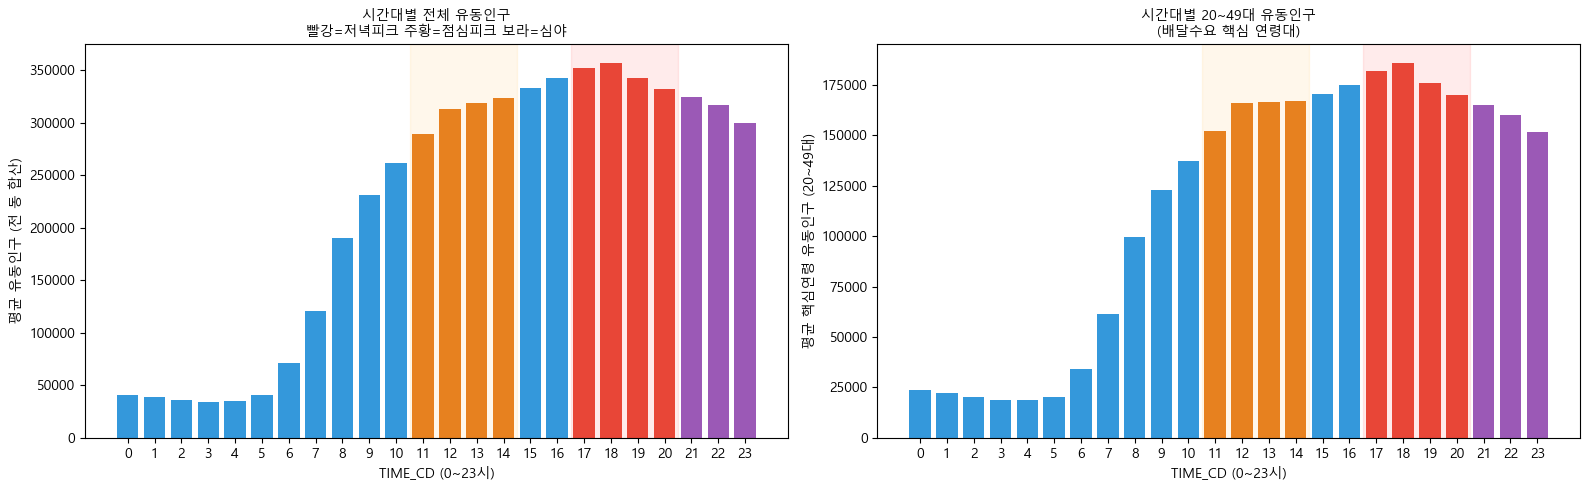

※ 구 방식은 FORN_GB 합산 없이 mean 사용 → 이 그래프보다 약 50% 작은 값이었음


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

g_h = hourly_agg.groupby('TIME_CD')[['avg_total_pop','avg_core_20_49_pop']].sum().sort_index()

def bar_color(tc):
    if tc in DINNER_HOURS: return '#e74c3c'
    if tc in LUNCH_HOURS:  return '#e67e22'
    if tc in LATE_NIGHT_HOURS: return '#9b59b6'
    return '#3498db'

colors = [bar_color(tc) for tc in g_h.index]

axes[0].bar(g_h.index, g_h['avg_total_pop'], color=colors)
axes[0].set_xticks(range(24))
axes[0].set_xlabel('TIME_CD (0~23시)')
axes[0].set_ylabel('평균 유동인구 (전 동 합산)')
axes[0].set_title('시간대별 전체 유동인구\n빨강=저녁피크 주황=점심피크 보라=심야', fontsize=10)

axes[1].bar(g_h.index, g_h['avg_core_20_49_pop'], color=colors)
axes[1].set_xticks(range(24))
axes[1].set_xlabel('TIME_CD (0~23시)')
axes[1].set_ylabel('평균 핵심연령 유동인구 (20~49대)')
axes[1].set_title('시간대별 20~49대 유동인구\n(배달수요 핵심 연령대)', fontsize=10)

for ax in axes:
    ax.axvspan(10.5, 14.5, alpha=0.08, color='orange', label='점심(11~14시)')
    ax.axvspan(16.5, 20.5, alpha=0.08, color='red',    label='저녁(17~20시)')

plt.tight_layout()
plt.show()
print('※ 구 방식은 FORN_GB 합산 없이 mean 사용 → 이 그래프보다 약 50% 작은 값이었음')

### 12-2. 상위 15개 동 프록시 지수 + 컴포넌트 기여도

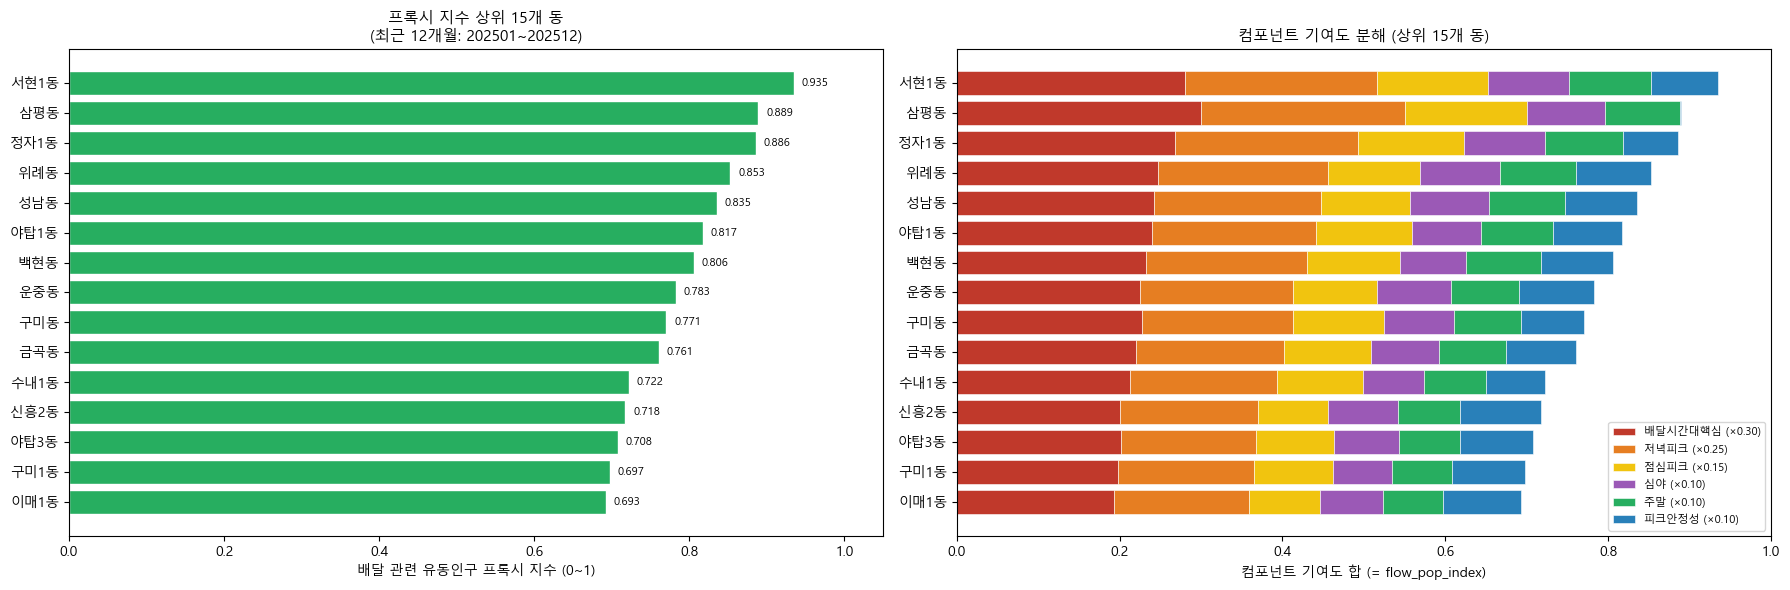

In [15]:
top15 = metrics.head(15).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 왼쪽: 종합 지수
axes[0].barh(top15['dong_nm'][::-1], top15['flow_pop_index'][::-1],
             color='#27ae60', edgecolor='white')
axes[0].set_xlabel('배달 관련 유동인구 프록시 지수 (0~1)')
axes[0].set_title(f'프록시 지수 상위 15개 동\n(최근 12개월: {recent_start}~{recent_end})', fontsize=11)
axes[0].set_xlim(0, 1.05)
for bar, val in zip(axes[0].patches, top15['flow_pop_index'][::-1]):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8)

# 오른쪽: 컴포넌트 기여도 스택 바
comp_info = [
    ('avg_delivery_hour_core_score', 0.30, '#c0392b', '배달시간대핵심 (×0.30)'),
    ('dinner_core_score',            0.25, '#e67e22', '저녁피크 (×0.25)'),
    ('lunch_core_score',             0.15, '#f1c40f', '점심피크 (×0.15)'),
    ('late_night_core_score',        0.10, '#9b59b6', '심야 (×0.10)'),
    ('weekend_core_score',           0.10, '#27ae60', '주말 (×0.10)'),
    ('peak_stability_score',         0.10, '#2980b9', '피크안정성 (×0.10)'),
]
dongs   = top15['dong_nm'].tolist()[::-1]
bottoms = np.zeros(len(dongs))
for col, w, color, label in comp_info:
    vals = (top15[col] * w).values[::-1]
    axes[1].barh(dongs, vals, left=bottoms, color=color,
                 label=label, edgecolor='white', linewidth=0.4)
    bottoms += vals

axes[1].set_xlabel('컴포넌트 기여도 합 (= flow_pop_index)')
axes[1].set_title('컴포넌트 기여도 분해 (상위 15개 동)', fontsize=11)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].set_xlim(0, 1)
plt.tight_layout()
plt.show()

### 12-3. 주말 vs 평일 유동인구 비교

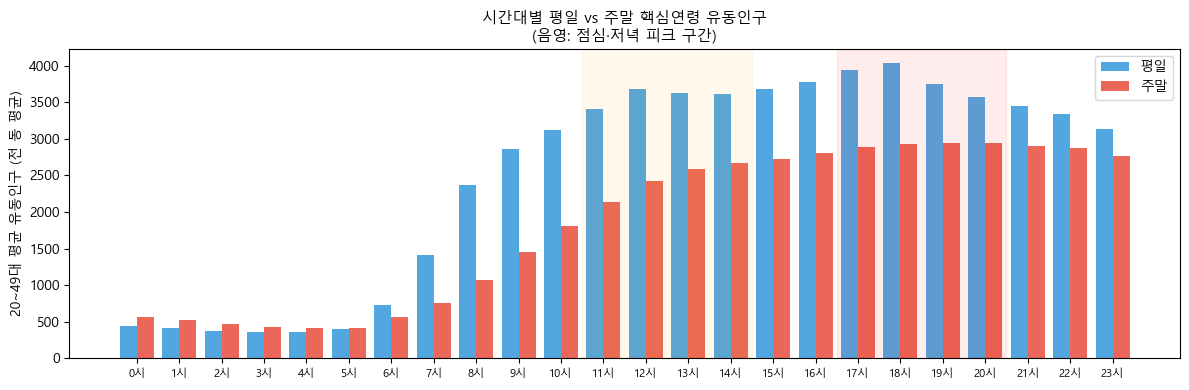

In [16]:
wkday_h = (
    df_recent
    .groupby(['TIME_CD','is_weekend'])['core_20_49_pop']
    .mean()
    .unstack('is_weekend')
    .rename(columns={False:'평일', True:'주말'})
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(24)
ax.bar(x - 0.2, wkday_h.get('평일', 0), width=0.4, label='평일', color='#3498db', alpha=0.85)
ax.bar(x + 0.2, wkday_h.get('주말', 0), width=0.4, label='주말', color='#e74c3c', alpha=0.85)
ax.axvspan(10.5, 14.5, alpha=0.07, color='orange')
ax.axvspan(16.5, 20.5, alpha=0.07, color='red')
ax.set_xticks(x)
ax.set_xticklabels([f'{h}시' for h in range(24)], fontsize=8)
ax.set_ylabel('20~49대 평균 유동인구 (전 동 평균)')
ax.set_title('시간대별 평일 vs 주말 핵심연령 유동인구\n(음영: 점심·저녁 피크 구간)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

## 13. 최종 출력 요약

In [17]:
print('=' * 62)
print('NB05 출력 파일 요약')
print('=' * 62)
outputs = [
    (out_agg,    '동별 배달 관련 유동인구 프록시 지수'),
    (out_hourly, '동별 시간대별 평균 유동인구'),
]
for path, desc in outputs:
    if path.exists():
        chk = pd.read_parquet(path)
        print(f'  ✓ {path.name:<35s}  {path.stat().st_size/1024:>6.0f} KB  {len(chk):>6,} rows  {desc}')
    else:
        print(f'  ✗ {path.name} — 파일 없음!')

print()
print(f'데이터 기간:     {all_yms[0]} ~ {all_yms[-1]}  ({len(all_yms)}개월)')
print(f'지수 산출 기간:  {recent_start} ~ {recent_end}  (최근 12개월)')
print(f'성남시 행정동:   {metrics["ADMI_CD"].nunique()}개')
print()
print('방법론 요약:')
print('  ① FORN_GB 합산 우선 → 내국인+외국인 총 유동인구')
print('  ② 핵심연령 20~49대 (5년 빈 20,25,30,35,40,45)')
print('  ③ 점심(11~14시)/저녁(17~20시)/심야(21~23시) 컴포넌트 분리')
print('  ④ log1p + 백분위 클리핑 min-max 정규화')
print('  ⑤ 6개 컴포넌트 가중합 = flow_pop_index')
print()
print('⚠ 이 지수는 유동인구 패턴 기반 프록시입니다.')
print('  실제 배달 주문 건수와 직접 비교하지 마세요.')

NB05 출력 파일 요약
  ✓ flow_pop_agg.parquet                     23 KB      50 rows  동별 배달 관련 유동인구 프록시 지수
  ✓ flow_pop_hourly.parquet                  53 KB   1,200 rows  동별 시간대별 평균 유동인구

데이터 기간:     202301 ~ 202512  (36개월)
지수 산출 기간:  202501 ~ 202512  (최근 12개월)
성남시 행정동:   50개

방법론 요약:
  ① FORN_GB 합산 우선 → 내국인+외국인 총 유동인구
  ② 핵심연령 20~49대 (5년 빈 20,25,30,35,40,45)
  ③ 점심(11~14시)/저녁(17~20시)/심야(21~23시) 컴포넌트 분리
  ④ log1p + 백분위 클리핑 min-max 정규화
  ⑤ 6개 컴포넌트 가중합 = flow_pop_index

⚠ 이 지수는 유동인구 패턴 기반 프록시입니다.
  실제 배달 주문 건수와 직접 비교하지 마세요.
